In [18]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
import json
import yaml
from scipy.spatial import KDTree

import geo_utils as gu

In [19]:
def get_spray_coverage(spray_zone, ndvi_map, ndvi_threshold):
    sprayed_area = (spray_zone >= 1)
    unhealthy_area = (ndvi_map < ndvi_threshold)
    spray_coverage = 100 * (np.sum(sprayed_area & unhealthy_area) / np.sum(unhealthy_area)) if np.sum(unhealthy_area) > 0 else 0
    return spray_coverage

In [20]:
algorithm = "greedy"
flight_path = np.load(f"Data/DronePaths_npy/{algorithm}.npy")

In [21]:
infected_points = []
infected_json = None
with open("Data/infected.json") as file:
    infected_json = json.load(file)

for point in infected_json:
    cy, cx = point["chunk_index"]
    y, x = gu.chunk_coord_to_pixel_coord(cy, cx, get_center=True)
    infected_points.append((y,x))

infected_tree = KDTree(infected_points)

with open("config.yaml") as file:
    config = yaml.safe_load(file)

In [22]:
#initializing a circular spray kernel

spray_zone = np.zeros_like(gu.ndvi)
spray_kernel = np.ones([gu.SPRAY_SIZE_PX, gu.SPRAY_SIZE_PX])

center = (gu.SPRAY_SIZE_PX//2, gu.SPRAY_SIZE_PX//2)
radius = gu.SPRAY_SIZE_PX // 2

for i in range(gu.SPRAY_SIZE_PX):
    for j in range(gu.SPRAY_SIZE_PX):
        if np.sqrt((i - center[0])**2 + (j - center[1])**2) > radius:
            spray_kernel[i,j]=0

def spray(zone, y, x, r=radius, kernel=spray_kernel, intensity=1):
    
    min_y = max(y - r, 0)
    max_y = min(y + r, zone.shape[0])
    min_x = max(x - r, 0)
    max_x = min(x + r, zone.shape[1])

    kernel_min_y = r - (y - min_y)
    kernel_max_y = r + (max_y - y)
    kernel_min_x = r - (x - min_x)
    kernel_max_x = r + (max_x - x)

    zone[min_y:max_y, min_x:max_x]+=kernel[kernel_min_y:kernel_max_y, kernel_min_x:kernel_max_x]*intensity

In [23]:
flight_time, spray_time = 0,0

for y in range(flight_path.shape[0]):
    for x in range(flight_path.shape[1]):
        if flight_path[y,x]:
            distance, idx = infected_tree.query((y,x))
            flight_time += 1

            if distance < gu.SPRAY_SIZE_PX:
                spray(spray_zone, y, x)
                spray_time += 1

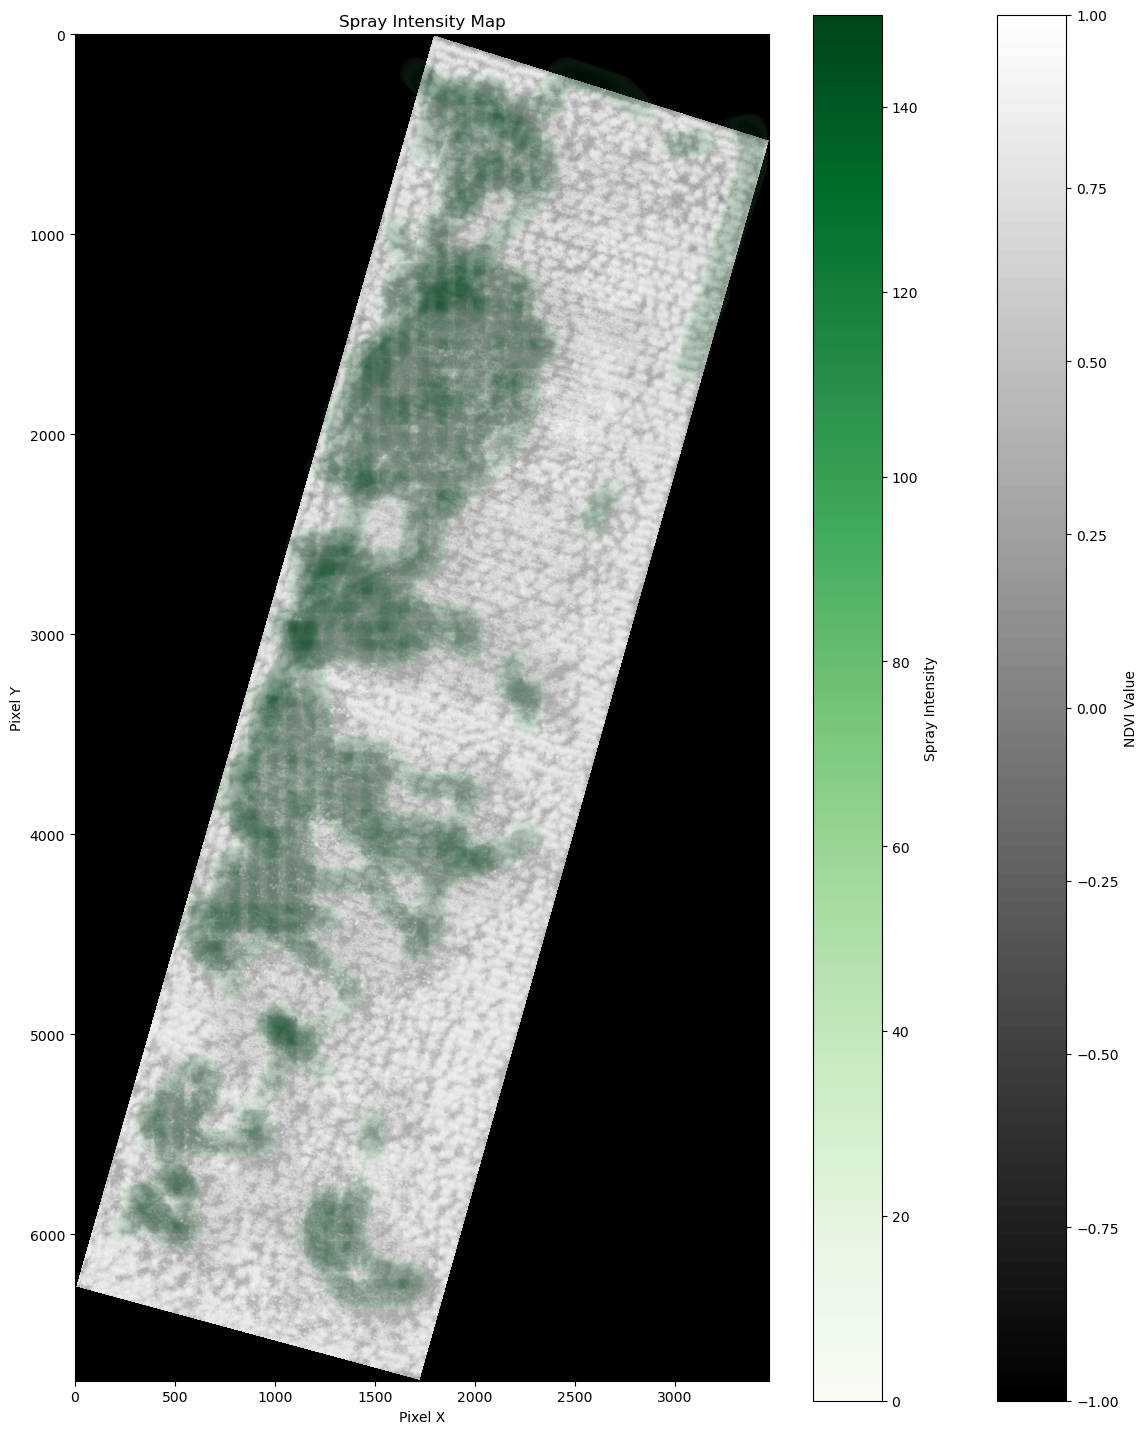

In [26]:
colors = [(0,0,0), (1,1,1)]
n_bins = 100
cmap = LinearSegmentedColormap.from_list("white_black", colors, N=n_bins)
norm = Normalize(vmin=-1, vmax=1)

plt.figure(figsize=(14, 18))
img = plt.imshow(gu.ndvi, cmap=cmap, norm=norm)
plt.colorbar(img, label='NDVI Value')

alpha_spray = 0.8
alpha_spray_matrix = np.clip(alpha_spray * spray_zone / spray_zone.max(), 0, 1)
overlay = plt.imshow(
    spray_zone,
    cmap="Greens",
    alpha=alpha_spray_matrix,
    vmin=0,
    vmax=150
)
plt.colorbar(overlay, label='Spray Intensity')

plt.title('Spray Intensity Map')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')

plt.savefig(f"Spray Patterns/{algorithm}.png")
plt.show()

Metrics of spraying strategy

Flight Efficiency = 100 * Time Spent Spraying / Time Spent Flying  
Spray Coverage = 100 * Unhealthy Area Sprayed / Total Unhealthy Area

In [25]:
flight_efficiency = 100 * spray_time / flight_time
spray_coverage = get_spray_coverage(spray_zone, gu.ndvi_m, config["infection_threshold_ndvi"])

print(f"Flight Efficiency: {flight_efficiency:.2f}%\nSpray Coverage: {spray_coverage:.2f}%")
with open(f"Spray Patterns/{algorithm}.txt", 'w') as f:
    f.write(f"Flight Efficiency: {flight_efficiency:.2f}%\nSpray Coverage: {spray_coverage:.2f}\n\n\nParams: {config}")

Flight Efficiency: 95.27%
Spray Coverage: 73.82%
